# Growth Rate Analysis

Reproduces the growth-rate box-whisker plot from **Omanović et al. (2025), Fig. 7**,  
applied to COSMO-SPECS plume-path data and HOLIMO observations.

**Method (Omanović et al. 2025):**
- Compute mean ice-crystal radius from bulk $q_i$ and ICNC, assuming spherical particles:  
  $r_i = \left(\frac{3\,q_i}{4\pi\,\rho_i\,N_i}\right)^{1/3}$
- Growth rate = $2\,r_i\,/\,\Delta t$ (diameter / growth time)
- Split samples by ICNC quantiles: all, P$_{5\%}$, P$_{95\%}$

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.collections import PatchCollection

xr.set_options(keep_attrs=True)

_src = next(
    (p / "src" for p in [Path.cwd(), *Path.cwd().parents]
     if (p / "src" / "utilities").is_dir()),
    (Path.cwd() / ".." / "src").resolve(),
)
sys.path.insert(0, str(_src))

from utilities import load_plume_path_runs

In [2]:
# ── Constants ──
RHO_ICE = 917  # kg/m³


def get_radius(n_m3, q_kgm3):
    """Mean ice-crystal radius [µm] from number conc. [m⁻³] and mass conc. [kg/m³]."""
    m = q_kgm3 / n_m3
    vol = m / RHO_ICE
    return ((3 * vol) / (4 * np.pi)) ** (1 / 3) * 1e6


def adjacent_values(vals, q1, q3):
    """Whisker bounds (1.5 × IQR, clipped to data range)."""
    iqr = q3 - q1
    upper = np.clip(q3 + 1.5 * iqr, q3, vals[-1])
    lower = np.clip(q1 - 1.5 * iqr, vals[0], q1)
    return lower, upper


# ── Multicolour legend helpers (Omanović et al. 2025) ──
class MulticolorPatch:
    def __init__(self, colors):
        self.colors = colors


class MulticolorPatchHandler:
    def legend_artist(self, legend, orig_handle, fontsize, handlebox):
        w, h = handlebox.width, handlebox.height
        patches = [
            plt.Rectangle(
                [w / len(orig_handle.colors) * i - handlebox.xdescent,
                 -handlebox.ydescent],
                w / len(orig_handle.colors), h,
                facecolor=c, edgecolor="none",
            )
            for i, c in enumerate(orig_handle.colors)
        ]
        patch = PatchCollection(patches, match_original=True)
        handlebox.add_artist(patch)
        return patch

## 1 — Configuration

In [3]:
PROCESSED_ROOT = Path("../data/processed")
HOLIMO_FILE = Path("../data/observations/holimo_data/CL_20230125_1000_1140_SM058_SM060_ts1.nc")

# Model runs to compare (uncomment / add as needed)
RUNS = [
    {"label": "ccn 0, run A",         "cs_run": "cs-eriswil__20251129_230943", "exp_id": "20251129231107"},
    {"label": "ccn 0, run B",         "cs_run": "cs-eriswil__20251129_230943", "exp_id": "20260119103733"},
    {"label": "ccn 400, spherical",   "cs_run": "cs-eriswil__20260121_131528", "exp_id": "20260121131550"},
    {"label": "ccn 400, columnar",    "cs_run": "cs-eriswil__20260121_131528", "exp_id": "20260121131632"},
    {"label": "ccn 400, analytic",    "cs_run": "cs-eriswil__20260127_211338", "exp_id": "20260127211431"},
    {"label": "ccn 400, planar",      "cs_run": "cs-eriswil__20260127_211338", "exp_id": "20260127211551"},
    # {"label": "ccn 0, spherical",   "cs_run": "cs-eriswil__20251125_114053", "exp_id": "20251125114238"},
    # {"label": "ccn 400, columnar (alt)", "cs_run": "cs-eriswil__20251125_114053", "exp_id": "20260120122711"},
]

# HOLIMO plume observation windows (same as CLOUDLAB campaign)
OBS_IDS = ["SM059", "SM058", "SM060"]
GROWTH_TIMES_MIN = [6.1, 8.0, 9.1]  # minutes (from Omanović et al.)
GROWTH_TIME_REF_S = np.mean(GROWTH_TIMES_MIN) * 60  # reference for model comparison

PLUME_KIND = "integrated"  # or 'extreme', 'vertical'

TIME_FRAMES_PLUME = [
    [np.datetime64("2023-01-25T10:55:00"), np.datetime64("2023-01-25T11:10:00")],
    [np.datetime64("2023-01-25T10:35:00"), np.datetime64("2023-01-25T10:50:00")],
    [np.datetime64("2023-01-25T11:24:00"), np.datetime64("2023-01-25T11:39:00")],
]

print(f"Reference growth time: {GROWTH_TIME_REF_S:.0f} s  ({GROWTH_TIME_REF_S/60:.1f} min)")
print(f"Runs to process: {len(RUNS)}")

Reference growth time: 464 s  (7.7 min)
Runs to process: 6


## 2 — Load model data & compute growth rates

In [4]:
datasets = load_plume_path_runs(
    RUNS,
    processed_root=PROCESSED_ROOT,
    kinds=(PLUME_KIND,),
)

# Collect growth-rate distributions per run
model_results = {}  # label → {"all": array, "p5": array, "p95": array}

for label, run_ds in datasets.items():
    ds = run_ds.get(PLUME_KIND)
    if ds is None or not isinstance(ds, xr.Dataset):
        print(f"  ⚠ {label}: no {PLUME_KIND} data")
        continue

    # Units: qi [g/L] → [kg/m³] (1 g/L = 1 kg/m³), icnc [L⁻¹] → [m⁻³] (* 1e3)
    qi_kgm3 = ds["qi"].values   # g/L = kg/m³
    icnc_m3 = ds["icnc"].values * 1e3  # L⁻¹ → m⁻³

    # Filter: require positive icnc
    valid = icnc_m3 > 1.0  # at least 1 m⁻³ ≈ 0.001 L⁻¹
    qi_f = np.where(valid, qi_kgm3, np.nan)
    icnc_f = np.where(valid, icnc_m3, np.nan)

    ri = get_radius(icnc_f, qi_f)  # µm
    gr = 2 * ri / GROWTH_TIME_REF_S  # µm/s

    # Flatten across cells and time
    gr_flat = gr.ravel()
    icnc_flat = icnc_f.ravel()
    mask = np.isfinite(gr_flat) & np.isfinite(icnc_flat)
    gr_clean = gr_flat[mask]
    icnc_clean = icnc_flat[mask]

    # ICNC quantile split
    p5  = np.nanpercentile(icnc_clean, 5)
    p95 = np.nanpercentile(icnc_clean, 95)

    model_results[label] = {
        "all":  gr_clean,
        "p5":   gr_clean[icnc_clean <= p5],
        "p95":  gr_clean[icnc_clean >= p95],
    }
    print(f"  ✓ {label}: {len(gr_clean)} samples, "
          f"median={np.median(gr_clean):.3f} µm/s, "
          f"ICNC P5={p5/1e3:.2f} L⁻¹, P95={p95/1e3:.1f} L⁻¹")

print(f"\nLoaded {len(model_results)} model runs.")

  ✓ ccn 0, run A: 467 samples, median=0.262 µm/s, ICNC P5=0.02 L⁻¹, P95=86.9 L⁻¹
  ✓ ccn 0, run B: 376 samples, median=0.139 µm/s, ICNC P5=8.05 L⁻¹, P95=148.7 L⁻¹
  ✓ ccn 400, spherical: 245 samples, median=0.210 µm/s, ICNC P5=5.11 L⁻¹, P95=204.4 L⁻¹
  ✓ ccn 400, columnar: 472 samples, median=0.147 µm/s, ICNC P5=6.95 L⁻¹, P95=140.1 L⁻¹
  ✓ ccn 400, analytic: 267 samples, median=0.197 µm/s, ICNC P5=5.30 L⁻¹, P95=215.4 L⁻¹
  ✓ ccn 400, planar: 100 samples, median=0.148 µm/s, ICNC P5=7.39 L⁻¹, P95=160.1 L⁻¹

Loaded 6 model runs.


## 3 — Load HOLIMO observations & compute growth rates

In [5]:
from utilities.holimo_helpers import load_holimo_dataset

obs_grts_all = []
obs_grts_p5 = []
obs_grts_p95 = []

if HOLIMO_FILE.exists():
    hds = load_holimo_dataset(str(HOLIMO_FILE))

    for i, (obs_id, grt_min, tw) in enumerate(
        zip(OBS_IDS, GROWTH_TIMES_MIN, TIME_FRAMES_PLUME)
    ):
        grt_s = grt_min * 60  # seconds

        # Slice observation time window
        hds_sel = hds.sel(time=slice(tw[0], tw[1]))

        # Ice concentration (L⁻¹) and mean diameter (m) per timestep
        ice_conc = hds_sel["Ice_concentration"].values
        ice_md = hds_sel["Ice_meanD"].values  # meters

        # Growth rate = diameter / growth_time [µm/s]
        gr_obs = ice_md / grt_s * 1e6

        # Filter valid samples
        valid = np.isfinite(gr_obs) & (ice_conc > 0.001)
        gr_v = gr_obs[valid]
        ic_v = ice_conc[valid]

        obs_grts_all.append(gr_v)

        # P5 / P95 ICNC split
        if len(ic_v) > 10:
            p5 = np.percentile(ic_v, 5)
            p95 = np.percentile(ic_v, 95)
            obs_grts_p5.append(gr_v[ic_v <= p5])
            obs_grts_p95.append(gr_v[ic_v >= p95])

        print(f"  {obs_id}: {len(gr_v)} samples, "
              f"median GR = {np.median(gr_v):.3f} µm/s, "
              f"grt = {grt_min} min")

    obs_ds = {
        "all":  np.concatenate(obs_grts_all) if obs_grts_all else np.array([]),
        "p5":   np.concatenate(obs_grts_p5) if obs_grts_p5 else np.array([]),
        "p95":  np.concatenate(obs_grts_p95) if obs_grts_p95 else np.array([]),
    }
    print(f"\n  Obs total: {len(obs_ds['all'])} samples, "
          f"median = {np.median(obs_ds['all']):.3f} µm/s")
else:
    obs_ds = None
    print(f"HOLIMO file not found: {HOLIMO_FILE}")

  SM059: 178 samples, median GR = 0.342 µm/s, grt = 6.1 min
  SM058: 191 samples, median GR = 0.286 µm/s, grt = 8.0 min
  SM060: 103 samples, median GR = 0.329 µm/s, grt = 9.1 min

  Obs total: 472 samples, median = 0.316 µm/s


## 4 — Growth-rate box-whisker plot (Omanović et al. 2025 style)

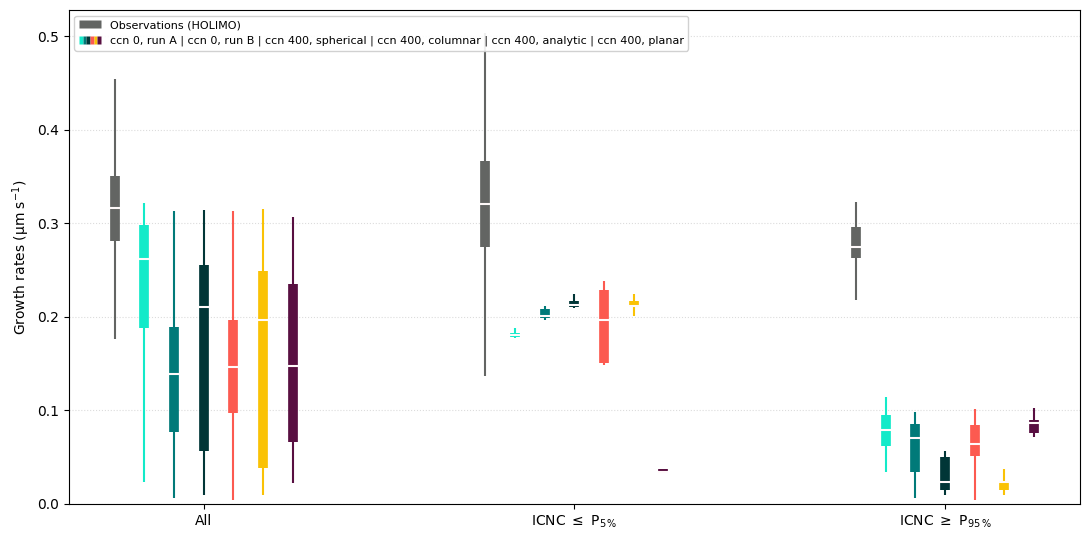

In [9]:
categories = ["all", "p5", "p95"]
cat_labels = ["All", r"ICNC $\leq$ P$_{5\,\%}$", r"ICNC $\geq$ P$_{95\,\%}$"]

# Colour palette for model runs
model_colors = [
    "xkcd:aqua", "xkcd:bluegreen", "#013637",
    "xkcd:coral", "xkcd:goldenrod", "xkcd:plum",
]
obs_col = "#636563"
n_models = len(model_results)

fig, ax = plt.subplots(figsize=(11., 5.5))

pos = np.arange(len(categories)) * 1.5
model_labels = list(model_results.keys())
shift_step = 0.12


def draw_whisker(ax, x, data, color, lw_box=7, lw_whisk=1.5):
    """Draw a single box-whisker element at position x."""
    data = data[np.isfinite(data)]
    if len(data) < 5:
        return
    q1, med, q3 = np.percentile(data, [25, 50, 75])
    wlo, whi = adjacent_values(np.sort(data), q1, q3)
    ax.scatter(x, med, marker="_", color="snow", s=50, zorder=3)
    ax.vlines(x, q1, q3, color=color, lw=lw_box)
    ax.vlines(x, wlo, whi, color=color, lw=lw_whisk)


# ── Observations ──
if obs_ds is not None and len(obs_ds["all"]) > 0:
    for ci, cat in enumerate(categories):
        draw_whisker(ax, pos[ci], obs_ds[cat], obs_col)

# ── Model runs ──
for mi, (mlabel, mdata) in enumerate(model_results.items()):
    col = model_colors[mi % len(model_colors)]
    for ci, cat in enumerate(categories):
        x = pos[ci] + (mi + 1) * shift_step
        draw_whisker(ax, x, mdata[cat], col)

# ── Axes ──
center_shift = (n_models * shift_step) / 2
ax.set_xticks(pos + center_shift)
ax.set_xticklabels(cat_labels)
ax.set_ylim(0.0, None)
ax.set_ylabel(r"Growth rates ($\mathrm{\mu}$m s$^{-1}$)")
ax.grid(axis="y", linestyle=":", color="gainsboro")

# ── Legend ──
h, l = [], []
if obs_ds is not None:
    h.append(MulticolorPatch([obs_col]))
    l.append("Observations (HOLIMO)")

used_colors = [model_colors[i % len(model_colors)] for i in range(n_models)]
h.append(MulticolorPatch(used_colors))
l.append(" | ".join(model_labels))

ax.legend(
    h, l,
    handler_map={MulticolorPatch: MulticolorPatchHandler()},
    loc="upper left",
    fontsize=8,
    framealpha=0.9,
)

fig.tight_layout()
plt.show()

## 5 — Summary statistics

In [8]:
rows = []

if obs_ds is not None and len(obs_ds["all"]) > 0:
    for cat in categories:
        d = obs_ds[cat]
        rows.append({
            "source": "Observations",
            "category": cat,
            "N": len(d),
            "median": np.median(d) if len(d) else np.nan,
            "p25": np.percentile(d, 25) if len(d) else np.nan,
            "p75": np.percentile(d, 75) if len(d) else np.nan,
        })

for mlabel, mdata in model_results.items():
    for cat in categories:
        d = mdata[cat]
        rows.append({
            "source": mlabel,
            "category": cat,
            "N": len(d),
            "median": np.median(d) if len(d) else np.nan,
            "p25": np.percentile(d, 25) if len(d) else np.nan,
            "p75": np.percentile(d, 75) if len(d) else np.nan,
        })

df_stats = pd.DataFrame(rows)
df_stats.style.format({"median": "{:.3f}", "p25": "{:.3f}", "p75": "{:.3f}"})

,source,category,N,median,p25,p75
0,Observations,all,472,0.316,0.281,0.350
1,Observations,p5,53,0.320,0.275,0.367
2,Observations,p95,25,0.275,0.262,0.296
3,"ccn 0, run A",all,467,0.262,0.188,0.298
4,"ccn 0, run A",p5,24,0.180,0.178,0.182
5,"ccn 0, run A",p95,24,0.079,0.061,0.095
6,"ccn 0, run B",all,376,0.139,0.077,0.190
7,"ccn 0, run B",p5,20,0.201,0.198,0.208
8,"ccn 0, run B",p95,19,0.070,0.034,0.086
9,"ccn 400, spherical",all,245,0.210,0.057,0.255
